In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
import os
import cv2
import tensorflow as tf
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.builders import model_builder
from object_detection.utils import config_util
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.xception import Xception #to get pre-trained model Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer #for text tokenization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.layers import concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import add
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense#Keras to build our CNN and LSTM
from tensorflow.keras.layers import LSTM, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint

In [23]:
CUSTOM_MODEL_NAME = 'my_ssd_mobnet' 
PRETRAINED_MODEL_NAME = 'ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8'
PRETRAINED_MODEL_URL = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz'
TF_RECORD_SCRIPT_NAME = 'generate_tfrecord.py'
LABEL_MAP_NAME = 'label_map.pbtxt'

In [24]:
paths = {
    'WORKSPACE_PATH': os.path.join('Tensorflow', 'workspace'),
    'SCRIPTS_PATH': os.path.join('Tensorflow','scripts'),
    'APIMODEL_PATH': os.path.join('Tensorflow','models'),
    'ANNOTATION_PATH': os.path.join('Tensorflow', 'workspace','annotations'),
    'IMAGE_PATH': os.path.join('Tensorflow', 'workspace','images'),
    'MODEL_PATH': os.path.join('Tensorflow', 'workspace','models'),
    'PRETRAINED_MODEL_PATH': os.path.join('Tensorflow', 'workspace','pre-trained-models'),
    'CHECKPOINT_PATH': os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME), 
    'OUTPUT_PATH': os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME, 'export'), 
    'TFJS_PATH':os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME, 'tfjsexport'), 
    'TFLITE_PATH':os.path.join('Tensorflow', 'workspace','models',CUSTOM_MODEL_NAME, 'tfliteexport'), 
    'PROTOC_PATH':os.path.join('Tensorflow','protoc')
 }

In [25]:
files = {
    'PIPELINE_CONFIG':os.path.join('Tensorflow', 'workspace','models', CUSTOM_MODEL_NAME, 'pipeline.config'),
    'TF_RECORD_SCRIPT': os.path.join(paths['SCRIPTS_PATH'], TF_RECORD_SCRIPT_NAME), 
    'LABELMAP': os.path.join(paths['ANNOTATION_PATH'], LABEL_MAP_NAME)
}


In [6]:
# Load dataset with meme images and descriptions
dataset = pd.read_csv("memes_dataset1.csv")

# Define classes and one-hot encode them
classes = ["distracted_boyfriend", "this_is_fine", "mocking_spongebob", "first_world_problems", "arthur_fist","surprised_pikachu","pointing_spiderman"]
# classes = ["Distracted boyfriend", "This is fine", "Mocking Spongebob", "First world problems", "Arthur fist"]

class_dict = dict(zip(classes, range(len(classes))))
print("Class dictionary: ", class_dict)

Class dictionary:  {'distracted_boyfriend': 0, 'this_is_fine': 1, 'mocking_spongebob': 2, 'first_world_problems': 3, 'arthur_fist': 4, 'surprised_pikachu': 5, 'pointing_spiderman': 6}


In [26]:
# Load pipeline config and build a detection model
configs = config_util.get_configs_from_pipeline_file(files['PIPELINE_CONFIG'])
detection_model = model_builder.build(model_config=configs['model'], is_training=False)

# Restore checkpoint
ckpt = tf.compat.v2.train.Checkpoint(model=detection_model)
ckpt.restore(os.path.join(paths['CHECKPOINT_PATH'], 'ckpt-3')).expect_partial()

@tf.function
def detect_fn(image):
    image, shapes = detection_model.preprocess(image)
    prediction_dict = detection_model.predict(image, shapes)
    detections = detection_model.postprocess(prediction_dict, shapes)
    return detections

In [8]:
import cv2 
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [27]:

category_index = label_map_util.create_category_index_from_labelmap(files['LABELMAP'])
folder_path = os.path.join(paths['IMAGE_PATH'], 'test')

In [10]:
category_index

{1: {'id': 1, 'name': 'distracted_boyfriend'},
 2: {'id': 2, 'name': 'this_is_fine'},
 3: {'id': 3, 'name': 'mocking_spongebob'},
 4: {'id': 4, 'name': 'first_world_problems'},
 5: {'id': 5, 'name': 'arthur_fist'},
 6: {'id': 6, 'name': 'surprised_pikachu'},
 7: {'id': 7, 'name': 'pointing_spiderman'}}

In [11]:
folder_path = os.path.join(paths['IMAGE_PATH'], 'test')

In [28]:
def detect(IMAGE_PATH):
    temp=None
    img = cv2.imread(IMAGE_PATH)
    image_np = np.array(img)
    input_tensor = tf.convert_to_tensor(np.expand_dims(image_np, 0), dtype=tf.float32)
    detections = detect_fn(input_tensor)

    num_detections = int(detections.pop('num_detections'))
    detections = {key: value[0, :num_detections].numpy()
                for key, value in detections.items()}
    detections['num_detections'] = num_detections

    # detection_classes should be ints.
    detections['detection_classes'] = detections['detection_classes'].astype(np.int64)

    label_id_offset = 1
    image_np_with_detections = image_np.copy()
    detected = detections['detection_classes']
    detected_names = [category_index[i + label_id_offset]['name'] for i in detected]
    detected_scores = detections['detection_scores']
    print('Detected objects:')
    for i in range(len(detected)):
        if detected_scores[i] > 0.9:
            print('\t{}: {:.2f}%'.format(detected_names[i], detected_scores[i]*100))
            temp=detected_names[i]
    return temp

In [30]:
detect('./static/images/img1.jpg')

ValueError: Creating variables on a non-first call to a function decorated with tf.function.

In [ ]:
y = dataset["Class"].apply(lambda x: class_dict[x]).values
y = to_categorical(y, num_classes=len(classes))

# Tokenize text descriptions
tokenizer = Tokenizer()
tokenizer.fit_on_texts(dataset["Description"])

In [ ]:
sequences = tokenizer.texts_to_sequences(dataset["Description"])
sequences
# Pad sequences to a fixed length
max_length = max([len(seq) for seq in sequences])
X = pad_sequences(sequences, maxlen=max_length, padding="post")

In [ ]:
descriptions=list(dataset['Description'])

In [ ]:
def define_model(num_classes, vocab_size, max_length):
    # Define input layer for meme class and one-hot encode the class
    class_input = Input(shape=(num_classes,))
    class_dense = Dense(units=256, activation='relu')(class_input)

    # Define input layer for text description
    text_input = Input(shape=(max_length,))
    emb = Embedding(input_dim=vocab_size, output_dim=256, mask_zero=True)(text_input)
    lstm = LSTM(units=256)(emb)

    # Merge the class and LSTM output
    decoder1 = concatenate([class_dense, lstm])
    decoder2 = Dense(units=256, activation='relu')(decoder1)
    output = Dense(units=vocab_size, activation='softmax')(decoder2)

    # Define the model
    model = Model(inputs=[class_input, text_input], outputs=output)

    # Compile the model
    model.compile(loss='categorical_crossentropy', optimizer='adam')

    # Print the model summary and save a visualization of the model architecture to a file
    print(model.summary())
    plot_model(model, to_file='model.png', show_shapes=True)

    return model


In [ ]:
import numpy as np
def data_generator(descriptions, classes, tokenizer, max_length, batch_size):
    target=list()
    x=list()
    labels=list()
    n=0
    # loop for ever over images
    while True:
        for j in range(len(descriptions)):
            n+=1
            # retrieve the photo feature
            class1 = classes[j]

            # encode the sequence
            seq = tokenizer.texts_to_sequences([descriptions[j]])[0]
            # split one sequence into multiple X, y pairs
            for i in range(1, len(seq)):
                # split into input and output pair
                in_seq, out_seq = seq[:i], seq[i]
                # pad input sequence
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                # encode output sequence
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                target.append(out_seq)
                x.append(in_seq)
                y = to_categorical(class_dict[class1], num_classes=7)
                labels.append(y)
            # batch size reached
            if n==batch_size:
                yield ([np.array(labels), np.array(x)], np.array(target))  # should yeild (61, 5) (61, 24) (61, 166)
                X1, X2, y = list(), list(), list()
                n=0


In [ ]:
num_classes = len(dataset['Class'].unique())
num_classes


7

In [ ]:
# Define the captioning model
vocab_size = len(tokenizer.word_index) + 1
model = define_model(num_classes, vocab_size, max_length)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 24)]         0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 7)]          0           []                               
                                                                                                  
 embedding (Embedding)          (None, 24, 256)      52736       ['input_3[0][0]']                
                                                                                                  
 dense (Dense)                  (None, 256)          2048        ['input_2[0][0]']                
                                                                                              

In [ ]:
#To check the shape of the input and output for your model
[l,x],Y = next(data_generator(dataset['Description'], dataset['Class'], tokenizer, max_length,5))
print(l.shape, x.shape, Y.shape) # should print (61, 5) (61, 24) (61, 166)


(61, 7) (61, 24) (61, 206)


In [ ]:
model = load_model('./models_v6/model_9.h5') # Change v2 to v3 or any new model folder if created and trained again

In [ ]:
pred=model.predict([l[0:2],x[0:2]])[0].argmax()

1/1 [==============================] - 0s 32ms/step


In [ ]:
def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

In [ ]:
def generate_desc(img,tokenizer):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        pred = model.predict([img,sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'end':
            break
    return in_text

In [ ]:
def get_img():
    img=input('Enter image name: '+str(class_dict.keys()))
    temp = np.zeros((1,num_classes))
    temp[0][class_dict[img]]=1
    return temp

In [ ]:
class_dict

{'distracted_boyfriend': 0,
 'this_is_fine': 1,
 'mocking_spongebob': 2,
 'first_world_problems': 3,
 'arthur_fist': 4,
 'surprised_pikachu': 5,
 'pointing_spiderman': 6}

In [ ]:
img=get_img()
words=generate_desc(img,tokenizer).split()

In [ ]:
for i in range(1,len(words)-1):
    if words[i]==words[i+1]:
        continue
    print(words[i],end=' ')

still image from the spider man animated series of two spider men pointing at each other 

In [ ]:
def get_description(img_path):
    img=detect(img_path)
    temp = np.zeros((1,num_classes))
    temp[0][class_dict[img]]=1
    words=generate_desc(temp,tokenizer).split()
    for i in range(1,len(words)-1):
        if words[i]==words[i+1]:
            continue
        print(words[i],end=' ')
    

In [18]:
get_description(r'C:\Users\crkpn\Documents\Programs\barani\TFODCourse\TFODCourse\Tensorflow\workspace\images\test\11f.jpg')

NameError: name 'get_description' is not defined

Detected objects:
	arthur_fist: 97.30%


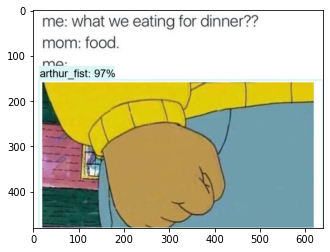

cartoon character named arthur clenches his fist enough to fine time 

In [ ]:
get_description(r'C:\Users\crkpn\Documents\Programs\barani\TFODCourse\TFODCourse\Tensorflow\workspace\images\test\11f.jpg')

Detected objects:
	mocking_spongebob: 99.39%


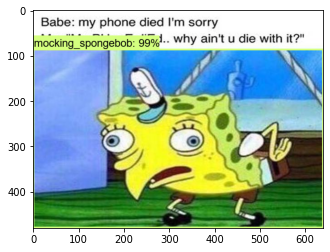

picture of spongebob squarepants with alternating uppercase and lowercase letters in the caption in the caption my mocking 

In [ ]:
get_description(r'C:\Users\crkpn\Documents\Programs\barani\TFODCourse\TFODCourse\Tensorflow\workspace\images\test\360px-Mocking_SpongeBob_meme_3.jpg')

Detected objects:
	this_is_fine: 98.82%


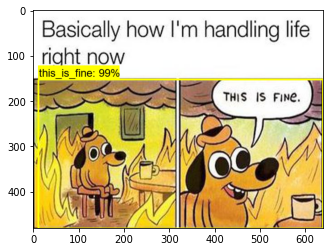

dog sits in a bad room but pretend like it's not affecting you affecting you affecting you affecting you affecting you affecting you 

In [ ]:
get_description(r'C:\Users\crkpn\Documents\Programs\barani\TFODCourse\TFODCourse\Tensorflow\workspace\images\test\360px-This_Is_Fine_meme_1.jpg')

Detected objects:
	pointing_spiderman: 99.53%


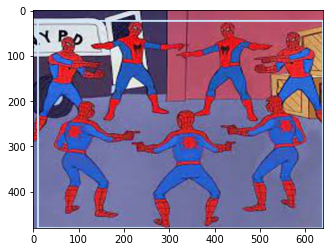

still image from the spider man animated series of two spider men pointing at each other 

In [ ]:
get_description(r'C:\Users\crkpn\Documents\Programs\barani\TFODCourse\TFODCourse\Tensorflow\workspace\images\test\spider2.jpg')

Detected objects:
	first_world_problems: 98.77%


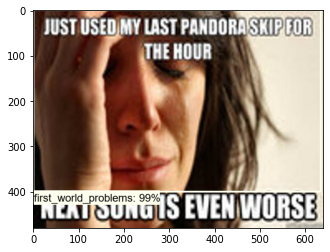

upset man holding a phone the caption my phone charger isn't long enough to reach my bed 

In [ ]:
get_description(r'C:\Users\crkpn\Documents\Programs\barani\TFODCourse\TFODCourse\Tensorflow\workspace\images\test\357xdk.jpg')